In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from scipy.stats import uniform, loguniform, norm
from sklearn.gaussian_process.kernels import Matern, RBF, WhiteKernel, ConstantKernel as C
from scipy.optimize import minimize
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score

## **Function 6** - Cake Recipie Optimisation

- This function is about optimising a cake recipe using a black-box function with five ingredient inputs, for example flour, sugar, eggs, butter and milk.
  - Each recipe is evaluated with a combined score based on _flavour_, _consistency_, _calories_, _waste_ and _cost_, where each factor contributes **negative points** as judged by an expert taster. This means the total score is negative by design.

- **Goal** - maximisation problem, your goal is to _bring that score as close to zero_ as possible or, equivalently, to maximise the negative of the total sum.

- **Input** - 5D (20,5)
- **Output** - 5D (20,)
- **Goal** - maximisation


In [2]:
X = np.load(r'C:\Users\Pratham\OneDrive\Imperial - Machine Learning and Artifical Intelligence Certification\Capstone\Weekly Capstone Updates and Comments\Week 1\Initial_data_points_starter\initial_data\function_6\initial_inputs.npy')
Y = np.load(r'C:\Users\Pratham\OneDrive\Imperial - Machine Learning and Artifical Intelligence Certification\Capstone\Weekly Capstone Updates and Comments\Week 1\Initial_data_points_starter\initial_data\function_6\initial_outputs.npy')

In [3]:
# New data from the first submission (example inputs and outputs)
X_w1_new_point = np.array([0.441233, 0.998122, 0.001245, 0.556711, 0.321098], dtype=np.float64)
Y_w1_new_point = np.array([-1.7775087544341799], dtype=np.float64)

# Append the new data points
X_updated = np.vstack((X, X_w1_new_point))
Y_updated = np.append(Y, Y_w1_new_point)

# Save the updated arrays
np.save(r'C:\Users\Pratham\OneDrive\Imperial - Machine Learning and Artifical Intelligence Certification\Capstone\Weekly Capstone Updates and Comments\Week 1\Initial_data_points_starter\initial_data\function_6\initial_inputs.npy', X_updated)
np.save(r'C:\Users\Pratham\OneDrive\Imperial - Machine Learning and Artifical Intelligence Certification\Capstone\Weekly Capstone Updates and Comments\Week 1\Initial_data_points_starter\initial_data\function_6\initial_outputs.npy', Y_updated)

In [4]:
print("Updated Inputs (X) - Function 6: ", X_updated)
print("Updated Outputs (Y) - Function 6: ", Y_updated)

Updated Inputs (X) - Function 6:  [[0.7281861  0.15469257 0.73255167 0.69399651 0.05640131]
 [0.24238435 0.84409997 0.5778091  0.67902128 0.50195289]
 [0.72952261 0.7481062  0.67977464 0.35655228 0.67105368]
 [0.77062024 0.11440374 0.04677993 0.64832428 0.27354905]
 [0.6188123  0.33180214 0.18728787 0.75623847 0.3288348 ]
 [0.78495809 0.91068235 0.7081201  0.95922543 0.0049115 ]
 [0.14511079 0.8966846  0.89632223 0.72627154 0.23627199]
 [0.94506907 0.28845905 0.97880576 0.96165559 0.59801594]
 [0.12572016 0.86272469 0.02854433 0.24660527 0.75120624]
 [0.75759436 0.35583141 0.0165229  0.4342072  0.11243304]
 [0.5367969  0.30878091 0.41187929 0.38822518 0.5225283 ]
 [0.95773967 0.23566857 0.09914585 0.15680593 0.07131737]
 [0.6293079  0.80348368 0.81140844 0.04561319 0.11062446]
 [0.02173531 0.42808424 0.83593944 0.48948866 0.51108173]
 [0.43934426 0.69892383 0.42682022 0.10947609 0.87788847]
 [0.25890557 0.79367771 0.6421139  0.19667346 0.59310318]
 [0.43216593 0.71561781 0.3418191  0.7

### **Interpretation of the outputs and steps for the future**

- In this cake recipe problem, every factor (cost, waste, calories) contributes negative points.
  - Since my goal is to bring that score as close to zero as possible.
  - Since our output = -1.778, it means my random recipe is already quite competitive, but it still has room to reduce "waste" points by fine-tuning ingredients like flour, sugar, or butter.

- To make sure that I am making this even better I will use ARD to make sure I know exactly which ingredient is impacting the overall recipie in what way.

- Finally, similar to the previous functions, I want to use the Gaussian process with an Expected Improvement (EI) surrogate model to find the next querey in order to improve the recipie score.


### **Bayesian Optimisation** - Matern kernel


- I want to use Matern with nu=2.5 because it allows for "twice-differentiable" smoothness.
  - This is ideal for a cake recipe where ingredient changes (like sugar) usually result in smooth but distinct changes in taste.

- There is another thing I would like to try in this first exploration is by passing a list of 5 length scales ([1.0]\*5).
  - The goal here is to make the Matern kernel learn which of the 5 ingredients (Flour, Sugar, etc.) actually drives the score

- I have also increased the n_restarts_optimiser to ensure a robust fit to the simpler kernel.


In [5]:
kernel = Matern(length_scale=[1.0]*5, nu=2.5)

model = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=30,
    alpha=1e-3,
    normalize_y=True,
    random_state=42
)

model.fit(X_updated, Y_updated)

GaussianProcessRegressor(alpha=0.001,
                         kernel=Matern(length_scale=[1, 1, 1, 1, 1], nu=2.5),
                         n_restarts_optimizer=30, normalize_y=True,
                         random_state=42)

### **Acquisition Function** - Expected Improvement (EI)

- As EI is an industry standard for 4D+ spaces because _it excels at balancing the "**high risk/high reward**" of unexplored areas with the "**safe bet**" of refining near existing good results._


In [6]:
def expected_improvement(X_grid, model, y_max, xi=0.01):
    mu, sigma = model.predict(X_grid, return_std=True)
    mu, sigma = mu.reshape(-1, 1), sigma.reshape(-1, 1)
    
    with np.errstate(divide='ignore', invalid='ignore'):
        improvement = mu - y_max - xi
        Z = improvement / (sigma + 1e-9)
        ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma <= 0.0] = 0.0
    return ei.ravel()

y_max = np.max(Y_updated)
x_grid = np.random.uniform(0, 1, size=(250000, 5))
ei_values = expected_improvement(x_grid, model, y_max, xi=0.01)

best_idx = np.argmax(ei_values)
next_query = x_grid[best_idx]

print(f"Next Submission for Function 6 - Bayesian Optimisation (EI): "
        f"{next_query[0]:.6f}-{next_query[1]:.6f}-{next_query[2]:.6f}-{next_query[3]:.6f}-{next_query[4]:.6f}")

Next Submission for Function 6 - Bayesian Optimisation (EI): 0.727708-0.335856-0.785846-0.777106-0.230214


### **Visualisation of the Search Map and Progress Plot**


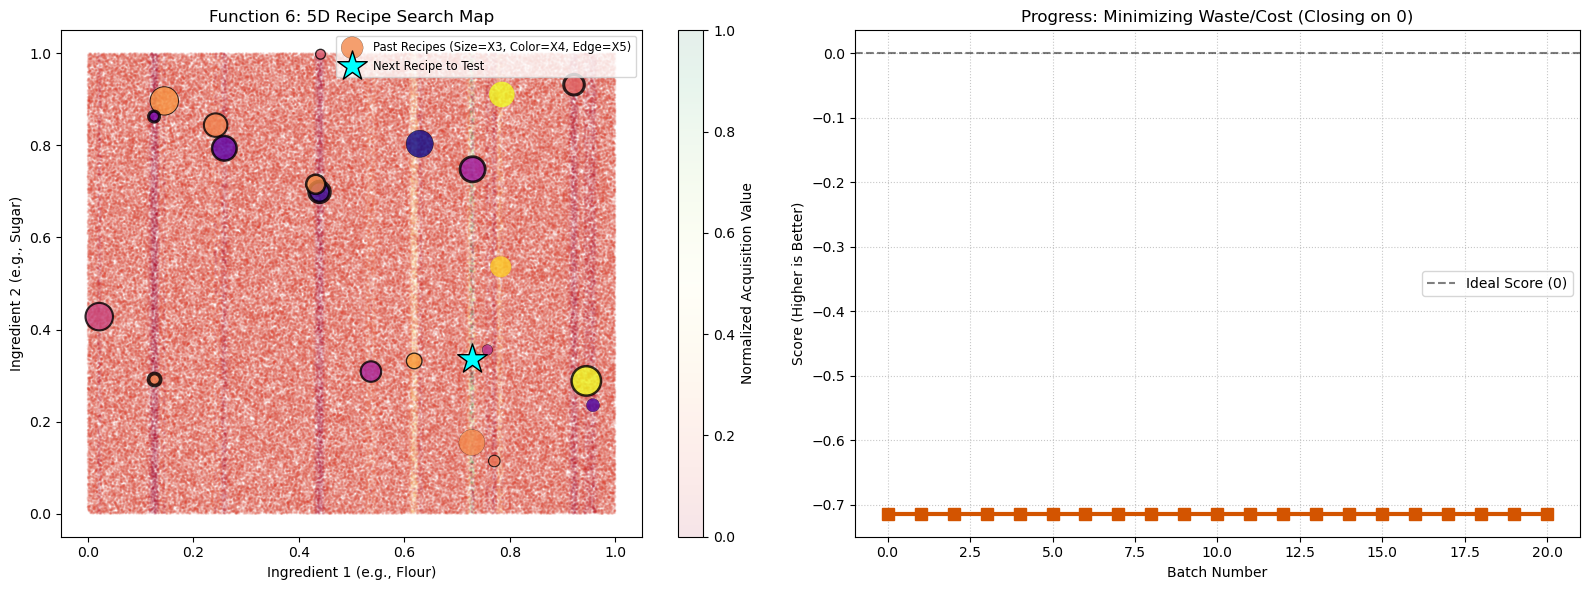

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup Progress Tracking
# We want the 'Maximum' signal, which for Function 6 means the least negative value
running_max = np.maximum.accumulate(Y_updated)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 2. Normalize Dimensions 3, 4, and 5 for the plot
# Scaling X3 for Size, X4 for Color, and using X5 to influence transparency or edge
x3_scaled = (X_updated[:, 2] - np.min(X_updated[:, 2])) / (np.ptp(X_updated[:, 2]) + 1e-12)
past_sizes = 50 + (400 * x3_scaled) 

# 3. The Search Map: 5D Projection
# Background: Normalized Acquisition Function (EI or PI)
acq_norm = (ei_values - np.nanmin(ei_values)) / (np.nanmax(ei_values) - np.nanmin(ei_values) + 1e-12)

sc = ax1.scatter(x_grid[:, 0], x_grid[:, 1], c=acq_norm, cmap='RdYlGn', s=1, alpha=0.1)
cbar = plt.colorbar(sc, ax=ax1, label='Normalized Acquisition Value')

# Past Samples: 
# Color = 4th Dim (X4), Size = 3rd Dim (X3), Alpha/Edge controlled by 5th Dim (X5)
past_sc = ax1.scatter(X_updated[:, 0], X_updated[:, 1], 
                      c=X_updated[:, 3], 
                      cmap='plasma', 
                      s=past_sizes, 
                      edgecolors='black', 
                      linewidth=X_updated[:, 4] * 3, # Edge thickness based on 5th dim
                      alpha=0.8, 
                      label='Past Recipes (Size=X3, Color=X4, Edge=X5)')

# Next Query: The "Optimized" Cake Recipe
ax1.scatter(next_query[0], next_query[1], c='cyan', marker='*', s=500, edgecolors='black', label='Next Recipe to Test')

ax1.set_title('Function 6: 5D Recipe Search Map')
ax1.set_xlabel('Ingredient 1 (e.g., Flour)')
ax1.set_ylabel('Ingredient 2 (e.g., Sugar)')
ax1.legend(loc='upper right', fontsize='small')

# 4. Progress Plot: Approaching Zero
ax2.plot(running_max, color='#d35400', linewidth=3, marker='s', markersize=8)
ax2.axhline(0, color='black', linestyle='--', alpha=0.5, label='Ideal Score (0)')
ax2.set_title('Progress: Minimizing Waste/Cost (Closing on 0)')
ax2.set_xlabel('Batch Number')
ax2.set_ylabel('Score (Higher is Better)')
ax2.grid(True, linestyle=':', alpha=0.7)
ax2.legend()

plt.tight_layout()
plt.show()